Setup OK
Genres: 10
Loading: children... 421,635 train rows (dropped 52,319 val/test)
Loading: comics_-graphic... 368,635 train rows (dropped 64,078 val/test)
Loading: fantasy_-paranormal... 2,182,613 train rows (dropped 195,644 val/test)
Loading: fiction... 2,825,122 train rows (dropped 281,119 val/test)
Loading: history_-historical-fiction_-biography... 529,994 train rows (dropped 52,363 val/test)
Loading: mystery_-thriller_-crime... 1,093,517 train rows (dropped 154,626 val/test)
Loading: non-fiction... 1,183,487 train rows (dropped 134,729 val/test)
Loading: poetry... 101,445 train rows (dropped 14,985 val/test)
Loading: romance... 1,916,118 train rows (dropped 289,047 val/test)
Loading: young-adult... 943,901 train rows (dropped 78,558 val/test)

Tong train edges: 11,566,467
Unique users:     233,321
Unique books:     1,600,156
edge_weight stats:
count    1.156647e+07
mean     2.685317e-01
std      5.238178e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75% 

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded → vngclinh/goodreads-preprocessed/graph/user_genre_affinity.parquet


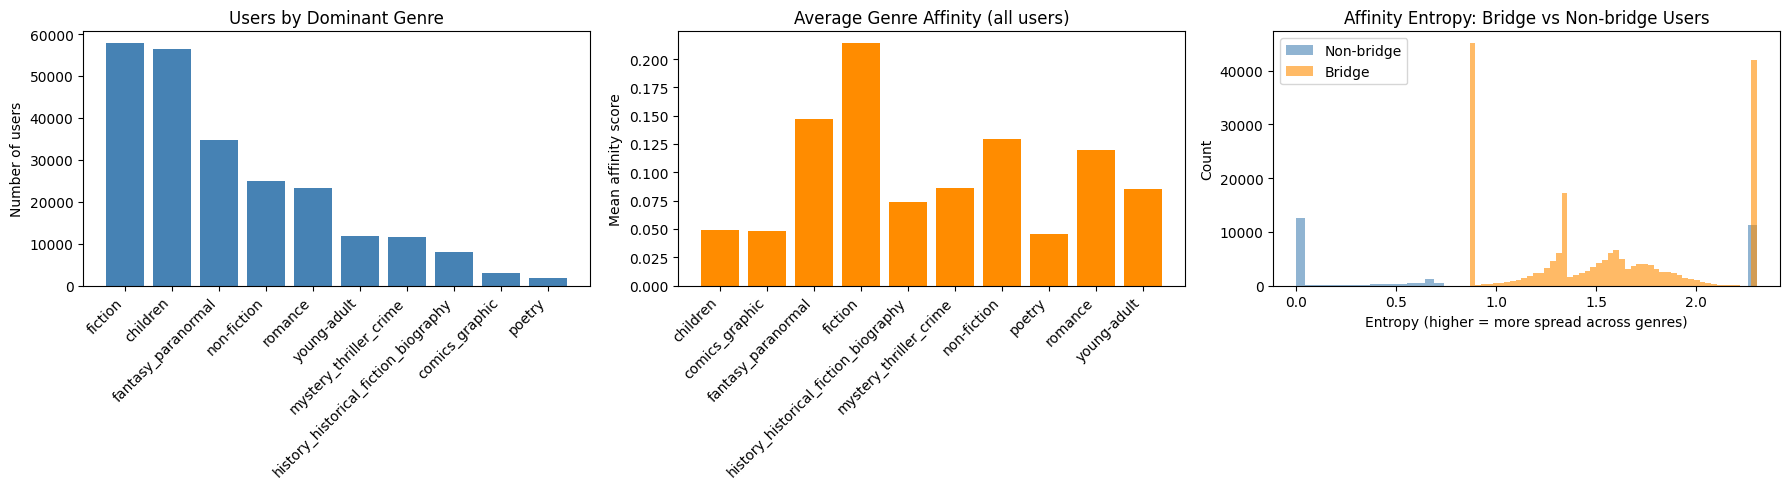

Plot saved → /kaggle/working/graph/affinity_analysis.png


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


=== BRANCH B COMPLETE ===
Output: vngclinh/goodreads-preprocessed/graph/user_genre_affinity.parquet
Rows:   233,321 users
Cols:   user_id + 10 genre affinity scores

Next step: Phase 3 — Merge Branch A + Branch B
  Input A: lda/book_topic_vectors.parquet
  Input B: graph/user_genre_affinity.parquet


In [6]:
# ============================================================
# BRANCH B — User-Genre Graph Affinity
# Notebook: tao moi tren Kaggle, chay doc lap voi Branch A
# Input:  vngclinh/goodreads-preprocessed/data/*.parquet
# Output: vngclinh/goodreads-preprocessed/graph/user_genre_affinity.parquet
# Thoi gian uoc tinh: ~20-25 phut
# ============================================================


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — Setup & Connect HuggingFace                   ║
# ╚══════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import os
from scipy.sparse import csr_matrix
from huggingface_hub import HfApi, HfFileSystem
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
HF_REPO  = "vngclinh/goodreads-preprocessed"

hf_fs = HfFileSystem(token=HF_TOKEN)
api   = HfApi()

os.makedirs("/kaggle/working/graph", exist_ok=True)

# Tên file đúng với tên đã upload trong Phase 1
# (dùng hf_fs.ls() để verify nếu không chắc)
GENRE_FILES = [
    "children",
    "comics_-graphic",
    "fantasy_-paranormal",
    "fiction",
    "history_historical-fiction_biography",
    "mystery_thriller_crime",
    "non-fiction",
    "poetry",
    "romance",
    "young-adult",
]

# Label gọn để dùng làm tên cột output
GENRE_FILES = [
    "children",
    "comics_-graphic",
    "fantasy_-paranormal",
    "fiction",
    "history_-historical-fiction_-biography",
    "mystery_-thriller_-crime",
    "non-fiction",
    "poetry",
    "romance",
    "young-adult",
]

print("Setup OK")
print(f"Genres: {len(GENRE_FILES)}")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Load data từ HuggingFace                      ║
# ╚══════════════════════════════════════════════════════════╝
# Chỉ load 6 cột cần thiết để tiết kiệm RAM
# Chỉ dùng split=train để tránh data leakage

NEEDED_COLS = [
    "user_id",
    "book_id",
    "primary_genre",
    "edge_weight",
    "split",
    "is_bridge_user",
    "user_genre_count",
]

parts = []
for fname in GENRE_FILES:
    path = f"datasets/{HF_REPO}/data/{fname}.parquet"
    print(f"Loading: {fname}...", end=" ")
    with hf_fs.open(path, "rb") as f:
        df = pd.read_parquet(f, columns=NEEDED_COLS)
    n_before = len(df)
    df = df[df["split"] == "train"].copy()
    parts.append(df)
    print(f"{len(df):,} train rows (dropped {n_before - len(df):,} val/test)")
    del df

data = pd.concat(parts, ignore_index=True)
del parts

# Sanity check
print(f"\nTong train edges: {len(data):,}")
print(f"Unique users:     {data['user_id'].nunique():,}")
print(f"Unique books:     {data['book_id'].nunique():,}")
print(f"edge_weight stats:\n{data['edge_weight'].describe()}")
print(f"\nGenres trong data:")
print(data["primary_genre"].value_counts())


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — Encode IDs thành integer index                ║
# ╚══════════════════════════════════════════════════════════╝
# scipy sparse matrix yêu cầu integer row/col index
# Cần lưu lại mapping để decode kết quả sau

print("Building index mappings...")

user_ids = data["user_id"].unique()
book_ids = data["book_id"].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
book2idx = {b: i for i, b in enumerate(book_ids)}

n_users = len(user_ids)
n_books = len(book_ids)
n_genres = len(GENRE_FILES)

print(f"n_users:  {n_users:,}")
print(f"n_books:  {n_books:,}")
print(f"n_genres: {n_genres}")

# Map primary_genre sang genre index
# primary_genre trong data là tên đầy đủ, ví dụ "fantasy, paranormal"
# cần map sang index 0-9 theo thứ tự GENRE_FILES

# Lấy tên genre thực tế từ data để build mapping chính xác
actual_genres = sorted(data["primary_genre"].unique())
print(f"\nActual genre names trong data:")
for g in actual_genres:
    print(f"  '{g}'")

# Build genre2idx dựa trên tên thực tế
# (thứ tự sẽ khớp với GENRE_LABELS nếu sort đúng)
genre2idx = {g: i for i, g in enumerate(actual_genres)}
ACTUAL_GENRE_LABELS = [f"genre_{g.replace(', ', '_').replace(' ', '_')}"
                       for g in actual_genres]

print(f"\nGenre mapping:")
for g, i in genre2idx.items():
    print(f"  {i}: {g}")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — Build sparse matrices                         ║
# ╚══════════════════════════════════════════════════════════╝
# Matrix 1: user_book_mat (n_users x n_books) — weighted by edge_weight
# Matrix 2: book_genre_mat (n_books x n_genres) — binary mapping

print("Building user-book sparse matrix...")

u_rows = data["user_id"].map(user2idx).values
u_cols = data["book_id"].map(book2idx).values
u_vals = data["edge_weight"].fillna(0).clip(lower=0).values.astype(np.float32)

# Nếu cùng 1 cặp (user, book) xuất hiện nhiều lần (edge từ nhiều genre file)
# csr_matrix tự động cộng dồn → đúng behavior
user_book_mat = csr_matrix(
    (u_vals, (u_rows, u_cols)),
    shape=(n_users, n_books)
)

print(f"user_book_mat: {user_book_mat.shape} | nnz: {user_book_mat.nnz:,}")
print(f"Memory: ~{user_book_mat.data.nbytes / 1e6:.1f} MB")

# ── Book-genre matrix ──────────────────────────────────────
print("\nBuilding book-genre sparse matrix...")

# Lấy 1 genre per book (first occurrence, genre đã được assign ở preprocessing)
book_genre_series = (
    data.groupby("book_id")["primary_genre"]
    .first()
)

valid_books = book_genre_series.index[
    book_genre_series.index.isin(book2idx)
]
b_rows = np.array([book2idx[b] for b in valid_books])
b_cols = np.array([genre2idx[book_genre_series[b]] for b in valid_books])

book_genre_mat = csr_matrix(
    (np.ones(len(b_rows), dtype=np.float32), (b_rows, b_cols)),
    shape=(n_books, n_genres)
)

print(f"book_genre_mat: {book_genre_mat.shape} | nnz: {book_genre_mat.nnz:,}")

# Cleanup data để giải phóng RAM
del u_rows, u_cols, u_vals, b_rows, b_cols
del book_genre_series, valid_books
print("\nRAM freed after matrix build")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — Tính user-genre affinity (matrix multiply)    ║
# ╚══════════════════════════════════════════════════════════╝
# user_genre = user_book × book_genre
# Ý nghĩa: user A đọc book X với edge_weight 3.2,
#           book X thuộc Fantasy
#           → user A có raw Fantasy score += 3.2
print("Computing user-genre affinity (matrix multiply)...")

user_genre_raw = user_book_mat.dot(book_genre_mat)
if hasattr(user_genre_raw, 'toarray'):
    user_genre_raw = user_genre_raw.toarray()

print(f"Raw affinity shape: {user_genre_raw.shape}")
print(f"Sample row 0 (raw): {user_genre_raw[0]}")

# Normalize
row_sums = user_genre_raw.sum(axis=1, keepdims=True)
row_sums = np.where(row_sums < 1e-9, 1.0, row_sums)
user_genre_norm = user_genre_raw / row_sums  # ← dòng này bạn đang thiếu

# Xử lý zero users SAU khi đã có user_genre_norm
zero_mask = (user_genre_raw.sum(axis=1) < 1e-9)
print(f"Zero edge_weight users: {zero_mask.sum():,} → assigned uniform 1/{n_genres}")
user_genre_norm[zero_mask] = 1.0 / n_genres

print(f"\nSample row 0 (normalized): {user_genre_norm[0]}")
print(f"Row sum check (should be 1.0): {user_genre_norm[0].sum():.4f}")
print(f"Min affinity: {user_genre_norm.min():.6f}")
print(f"Max affinity: {user_genre_norm.max():.6f}")

del user_genre_raw, row_sums
print("\nRAM freed after normalization")

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — Bridge user smoothing                         ║
# ╚══════════════════════════════════════════════════════════╝
# Bridge users (doc >= 3 the loai) co affinity phan bo deu hon
# Blend 80% actual + 20% uniform → tranh model overfit 1 genre
# cho nhung user thuc su da the loai
# Cell 6 — Bridge user smoothing (fixed)
print("Applying bridge user smoothing...")

bridge_flags = (
    data.groupby("user_id")["is_bridge_user"]
    .first()
    .reindex(user_ids)
    .fillna(False)
    .values
    .astype(bool)
)

n_bridge = bridge_flags.sum()
print(f"Bridge users: {n_bridge:,} / {n_users:,} ({100*n_bridge/n_users:.1f}%)")

ALPHA = 0.2
uniform = np.full(n_genres, 1.0 / n_genres, dtype=np.float32)

affinity_final = user_genre_norm.copy()
affinity_final[bridge_flags] = (
    (1 - ALPHA) * user_genre_norm[bridge_flags] +
    ALPHA * uniform
)

# Re-normalize sau blend để đảm bảo row sum = 1
# (cần thiết vì user_genre_norm đã có zero-rows được gán uniform)
row_sums_final = affinity_final.sum(axis=1, keepdims=True)
row_sums_final = np.where(row_sums_final < 1e-9, 1.0, row_sums_final)
affinity_final = affinity_final / row_sums_final

# Verify
bridge_entropy    = -(affinity_final[bridge_flags] *
                      np.log(affinity_final[bridge_flags] + 1e-9)).sum(axis=1).mean()
nonbridge_entropy = -(affinity_final[~bridge_flags] *
                      np.log(affinity_final[~bridge_flags] + 1e-9)).sum(axis=1).mean()
print(f"Entropy bridge users:     {bridge_entropy:.4f}")
print(f"Entropy non-bridge users: {nonbridge_entropy:.4f}")
print("Bridge smoothing done")

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — Tạo DataFrame kết quả & validate              ║
# ╚══════════════════════════════════════════════════════════╝

print("Building result DataFrame...")

result_df = pd.DataFrame(
    affinity_final.astype(np.float32),
    columns=ACTUAL_GENRE_LABELS
)
result_df.insert(0, "user_id", user_ids)

print(f"\nResult shape: {result_df.shape}")
print(f"Columns: {result_df.columns.tolist()}")
print(f"\nSample rows:")
print(result_df.head(3).to_string())
# DEBUG — chạy trước validation
print(f"Row sum = 0: {(row_sums_check == 0).sum():,} users")
print(f"Row sum < 0.99: {(row_sums_check < 0.99).sum():,} users")
print(f"Row sum > 1.01: {(row_sums_check > 1.01).sum():,} users")
print(f"\nRow sum distribution:")
print(row_sums_check.describe())

# ── Validation checks ──────────────────────────────────────
print("\n--- Validation ---")

# 1. Row sums phải = 1.0
row_sums_check = result_df[ACTUAL_GENRE_LABELS].sum(axis=1)
print(f"Row sum min: {row_sums_check.min():.6f}")
print(f"Row sum max: {row_sums_check.max():.6f}")
assert (row_sums_check > 0.99).all(), f"ERROR: {(row_sums_check <= 0.99).sum()} users có row_sum < 0.99"
assert (row_sums_check < 1.01).all(), f"ERROR: {(row_sums_check >= 1.01).sum()} users có row_sum > 1.01"
print("Row sum check PASSED")

# 2. Không có NaN
n_nan = result_df.isnull().sum().sum()
print(f"NaN count: {n_nan} (should be 0)")
assert n_nan == 0, "ERROR: có NaN trong kết quả!"

# 3. Tất cả values trong [0, 1]
min_val = result_df[ACTUAL_GENRE_LABELS].min().min()
max_val = result_df[ACTUAL_GENRE_LABELS].max().max()
print(f"Value range: [{min_val:.6f}, {max_val:.6f}] (should be [0,1])")
assert min_val >= 0, "ERROR: có giá trị âm!"
assert max_val <= 1, "ERROR: có giá trị > 1!"

# 4. Dominant genre check — mỗi user có 1 genre chiếm đa số
dominant = result_df[ACTUAL_GENRE_LABELS].idxmax(axis=1)
print(f"\nDistribution of dominant genre:")
print(dominant.value_counts())

print("\nAll validations PASSED!")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — Save local & Upload HuggingFace               ║
# ╚══════════════════════════════════════════════════════════╝

out_path = "/kaggle/working/graph/user_genre_affinity.parquet"
result_df.to_parquet(out_path, index=False)

file_size_mb = os.path.getsize(out_path) / 1e6
print(f"Saved local: {out_path}")
print(f"File size: {file_size_mb:.1f} MB")

print("\nUploading to HuggingFace...")
api.upload_file(
    path_or_fileobj=out_path,
    path_in_repo="graph/user_genre_affinity.parquet",
    repo_id=HF_REPO,
    repo_type="dataset",
    token=HF_TOKEN
)
print(f"Uploaded → {HF_REPO}/graph/user_genre_affinity.parquet")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Quick analysis (optional nhưng nên chạy)      ║
# ╚══════════════════════════════════════════════════════════╝
# Visualize để verify kết quả có ý nghĩa

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Phân phối dominant genre
dominant_counts = dominant.value_counts()
axes[0].bar(range(len(dominant_counts)),
            dominant_counts.values,
            color="steelblue")
axes[0].set_xticks(range(len(dominant_counts)))
axes[0].set_xticklabels(
    [g.replace("genre_", "") for g in dominant_counts.index],
    rotation=45, ha="right"
)
axes[0].set_title("Users by Dominant Genre")
axes[0].set_ylabel("Number of users")

# Plot 2: Average affinity per genre (toàn bộ users)
avg_affinity = result_df[ACTUAL_GENRE_LABELS].mean()
axes[1].bar(range(n_genres), avg_affinity.values, color="darkorange")
axes[1].set_xticks(range(n_genres))
axes[1].set_xticklabels(
    [g.replace("genre_", "") for g in ACTUAL_GENRE_LABELS],
    rotation=45, ha="right"
)
axes[1].set_title("Average Genre Affinity (all users)")
axes[1].set_ylabel("Mean affinity score")

# Plot 3: Bridge vs Non-bridge entropy distribution
bridge_mask = bridge_flags
entropy_bridge = -(
    affinity_final[bridge_mask] *
    np.log(affinity_final[bridge_mask] + 1e-9)
).sum(axis=1)
entropy_nonbridge = -(
    affinity_final[~bridge_mask] *
    np.log(affinity_final[~bridge_mask] + 1e-9)
).sum(axis=1)

axes[2].hist(entropy_nonbridge, bins=50, alpha=0.6,
             label="Non-bridge", color="steelblue")
axes[2].hist(entropy_bridge, bins=50, alpha=0.6,
             label="Bridge", color="darkorange")
axes[2].set_title("Affinity Entropy: Bridge vs Non-bridge Users")
axes[2].set_xlabel("Entropy (higher = more spread across genres)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/graph/affinity_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → /kaggle/working/graph/affinity_analysis.png")

# Upload plot lên HF
api.upload_file(
    path_or_fileobj="/kaggle/working/graph/affinity_analysis.png",
    path_in_repo="graph/affinity_analysis.png",
    repo_id=HF_REPO,
    repo_type="dataset",
    token=HF_TOKEN
)

print("\n=== BRANCH B COMPLETE ===")
print(f"Output: {HF_REPO}/graph/user_genre_affinity.parquet")
print(f"Rows:   {len(result_df):,} users")
print(f"Cols:   user_id + {n_genres} genre affinity scores")
print("\nNext step: Phase 3 — Merge Branch A + Branch B")
print("  Input A: lda/book_topic_vectors.parquet")
print("  Input B: graph/user_genre_affinity.parquet")

code cho toàn bộ 5 ct

In [1]:
# ============================================================
# BRANCH B — User-Genre Graph Affinity (All 5 Variants)
# ============================================================

import pandas as pd
import numpy as np
import os
from scipy.sparse import csr_matrix
from huggingface_hub import HfApi, HfFileSystem
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
HF_REPO  = "vngclinh/goodreads-preprocessed"
hf_fs    = HfFileSystem(token=HF_TOKEN)
api      = HfApi()
os.makedirs("/kaggle/working/graph", exist_ok=True)

GENRE_FILES = [
    "children", "comics_-graphic", "fantasy_-paranormal", "fiction",
    "history_-historical-fiction_-biography", "mystery_-thriller_-crime",
    "non-fiction", "poetry", "romance", "young-adult",
]

# ── CELL 2: Load train data ──────────────────────────────────
NEEDED_COLS = [
    "user_id", "book_id", "primary_genre", "edge_weight",
    "rating", "n_votes", "review_token_count",
    "split", "is_bridge_user",
]

parts = []
for fname in GENRE_FILES:
    path = f"datasets/{HF_REPO}/data/{fname}.parquet"
    print(f"Loading: {fname}...", end=" ")
    with hf_fs.open(path, "rb") as f:
        df = pd.read_parquet(f, columns=NEEDED_COLS)
    df = df[df["split"] == "train"].copy()
    parts.append(df)
    print(f"{len(df):,} train rows")
    del df

data = pd.concat(parts, ignore_index=True)
del parts

# Clean numeric cols
for col in ["rating", "n_votes", "review_token_count"]:
    data[col] = pd.to_numeric(data[col], errors="coerce").fillna(0).clip(lower=0)
data["rating"] = data["rating"].clip(upper=5)

print(f"Total train edges: {len(data):,}")
print(f"Unique users: {data['user_id'].nunique():,}")

# ── CELL 3: Build index mappings ─────────────────────────────
user_ids = data["user_id"].unique()
book_ids = data["book_id"].unique()
user2idx = {u: i for i, u in enumerate(user_ids)}
book2idx = {b: i for i, b in enumerate(book_ids)}
n_users, n_books = len(user_ids), len(book_ids)

actual_genres   = sorted(data["primary_genre"].unique())
genre2idx       = {g: i for i, g in enumerate(actual_genres)}
ACTUAL_GENRE_LABELS = [
    f"genre_{g.replace(', ', '_').replace(' ', '_')}"
    for g in actual_genres
]
n_genres = len(actual_genres)

print(f"n_users={n_users:,} | n_books={n_books:,} | n_genres={n_genres}")

# ── CELL 4: Book-genre matrix (shared across all variants) ───
book_genre_series = data.groupby("book_id")["primary_genre"].first()
valid_books = book_genre_series.index[book_genre_series.index.isin(book2idx)]
b_rows = np.array([book2idx[b] for b in valid_books])
b_cols = np.array([genre2idx[book_genre_series[b]] for b in valid_books])

book_genre_mat = csr_matrix(
    (np.ones(len(b_rows), dtype=np.float32), (b_rows, b_cols)),
    shape=(n_books, n_genres)
)
print(f"book_genre_mat: {book_genre_mat.shape}")
del b_rows, b_cols, book_genre_series, valid_books

# Bridge flags (shared)
bridge_flags = (
    data.groupby("user_id")["is_bridge_user"]
    .first().reindex(user_ids).fillna(False).values.astype(bool)
)
print(f"Bridge users: {bridge_flags.sum():,} ({100*bridge_flags.mean():.1f}%)")

# ── CELL 5: Define 5 edge weight formulas ────────────────────
rating_norm    = data["rating"] / 5.0
log_votes      = np.log1p(data["n_votes"])
log_review_len = np.log1p(data["review_token_count"])

VARIANTS = {
    "f1_rating_votes":         rating_norm * log_votes,
    "f2_rating_only":          rating_norm,
    "f3_rating_length":        rating_norm * log_review_len,
    "f4_rating_votes_length":  rating_norm * log_votes * log_review_len,
    "f5_binary_positive":      (data["rating"] >= 4).astype(np.float32),
}

u_rows = data["user_id"].map(user2idx).values
u_cols = data["book_id"].map(book2idx).values

# ── CELL 6: Loop over variants ───────────────────────────────
def build_and_upload(variant_name, edge_weights):
    print(f"\n{'='*60}")
    print(f"Variant: {variant_name}")
    print(f"{'='*60}")

    vals = edge_weights.values.astype(np.float32)
    vals = np.nan_to_num(vals, nan=0.0).clip(min=0)

    # Build user-book sparse matrix
    user_book_mat = csr_matrix(
        (vals, (u_rows, u_cols)),
        shape=(n_users, n_books)
    )

    # user_genre_raw = user_book × book_genre
    user_genre_raw = user_book_mat.dot(book_genre_mat)
    if hasattr(user_genre_raw, "toarray"):
        user_genre_raw = user_genre_raw.toarray()

    # Normalize rows
    row_sums = user_genre_raw.sum(axis=1, keepdims=True)
    zero_mask = (row_sums.squeeze() < 1e-9)
    row_sums = np.where(row_sums < 1e-9, 1.0, row_sums)
    user_genre_norm = user_genre_raw / row_sums
    user_genre_norm[zero_mask] = 1.0 / n_genres  # uniform for zero-edge users

    print(f"Zero-edge users: {zero_mask.sum():,} → assigned uniform")

    # Bridge smoothing: blend 80% actual + 20% uniform
    ALPHA   = 0.2
    uniform = np.full(n_genres, 1.0 / n_genres, dtype=np.float32)
    affinity = user_genre_norm.copy()
    affinity[bridge_flags] = (
        (1 - ALPHA) * user_genre_norm[bridge_flags] + ALPHA * uniform
    )
    # Re-normalize after blend
    rs = affinity.sum(axis=1, keepdims=True)
    affinity = affinity / np.where(rs < 1e-9, 1.0, rs)

    # Validate
    row_sums_check = affinity.sum(axis=1)
    assert (row_sums_check > 0.99).all() and (row_sums_check < 1.01).all(), \
        "Row sum validation failed!"
    assert not np.isnan(affinity).any(), "NaN detected!"
    print("✓ Validation passed")

    # Entropy check
    be  = -(affinity[bridge_flags]  * np.log(affinity[bridge_flags]  + 1e-9)).sum(axis=1).mean()
    nbe = -(affinity[~bridge_flags] * np.log(affinity[~bridge_flags] + 1e-9)).sum(axis=1).mean()
    print(f"Entropy — bridge: {be:.4f} | non-bridge: {nbe:.4f}")

    # Build result DataFrame
    result_df = pd.DataFrame(affinity.astype(np.float32), columns=ACTUAL_GENRE_LABELS)
    result_df.insert(0, "user_id", user_ids)

    # Save & upload
    out_path = f"/kaggle/working/graph/user_genre_affinity_{variant_name}.parquet"
    result_df.to_parquet(out_path, index=False)

    api.upload_file(
        path_or_fileobj=out_path,
        path_in_repo=f"graph/user_genre_affinity_{variant_name}.parquet",
        repo_id=HF_REPO, repo_type="dataset", token=HF_TOKEN
    )
    print(f"✓ Uploaded → graph/user_genre_affinity_{variant_name}.parquet")
    print(f"  Rows: {len(result_df):,} | Cols: {result_df.shape[1]}")

    del user_book_mat, user_genre_raw, user_genre_norm, affinity, result_df

for name, weights in VARIANTS.items():
    build_and_upload(name, weights)

print("\n=== ALL 5 BRANCH B VARIANTS COMPLETE ===")
for name in VARIANTS:
    print(f"  graph/user_genre_affinity_{name}.parquet")
print("\nNext: Phase 3 — run for each variant, then Phase 4 eval")

Loading: children... 346,374 train rows
Loading: comics_-graphic... 278,715 train rows
Loading: fantasy_-paranormal... 1,822,110 train rows
Loading: fiction... 2,362,637 train rows
Loading: history_-historical-fiction_-biography... 444,964 train rows
Loading: mystery_-thriller_-crime... 873,900 train rows
Loading: non-fiction... 980,423 train rows
Loading: poetry... 81,325 train rows
Loading: romance... 1,493,361 train rows
Loading: young-adult... 799,360 train rows
Total train edges: 9,483,169
Unique users: 219,385
n_users=219,385 | n_books=1,351,066 | n_genres=10
book_genre_mat: (1351066, 10)
Bridge users: 193,527 (88.2%)

Variant: f1_rating_votes
Zero-edge users: 57,846 → assigned uniform
✓ Validation passed
Entropy — bridge: 1.5496 | non-bridge: 1.0836


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✓ Uploaded → graph/user_genre_affinity_f1_rating_votes.parquet
  Rows: 219,385 | Cols: 11

Variant: f2_rating_only
Zero-edge users: 0 → assigned uniform
✓ Validation passed
Entropy — bridge: 1.5999 | non-bridge: 0.3542


Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

✓ Uploaded → graph/user_genre_affinity_f4_rating_votes_length.parquet
  Rows: 219,385 | Cols: 11

Variant: f5_binary_positive
Zero-edge users: 2,542 → assigned uniform
✓ Validation passed
Entropy — bridge: 1.5562 | non-bridge: 0.3489


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✓ Uploaded → graph/user_genre_affinity_f5_binary_positive.parquet
  Rows: 219,385 | Cols: 11

=== ALL 5 BRANCH B VARIANTS COMPLETE ===
  graph/user_genre_affinity_f1_rating_votes.parquet
  graph/user_genre_affinity_f2_rating_only.parquet
  graph/user_genre_affinity_f3_rating_length.parquet
  graph/user_genre_affinity_f4_rating_votes_length.parquet
  graph/user_genre_affinity_f5_binary_positive.parquet

Next: Phase 3 — run for each variant, then Phase 4 eval
